# MGT353 Forecasting Milestone 1
## Mustafa Arif | Colgate-Palmolive Pakistan | Colgate MaxFresh Red Gel 125g

Using dataset file: MGT353_Forecasting_M1_MustafaArif_ColgatePalmolive_Data.csv
Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Colgate-Palmolive (Pakistan)'s disclosed scale, not actual company records.
Rows: 156 | Date range: 2023-10-09 to 2026-09-28
Training weeks: 144 | Holdout weeks: 12


,mean,median,std,min,max,range,cv
Actual_Demand,"329,005","314,266","50,541","221,522","454,986","233,464",15.4%
Historical_Forecast,"348,276","346,700","32,917","281,700","459,500","177,800",9.5%
Price,304,302,27,255,348,93,8.8%
Promo_Depth,3,0,5,0,15,15,162.0%
Distribution_Points,191,192,5,181,203,22,2.8%



DEMAND PATTERN DIAGNOSIS
 Colgate MaxFresh Red Gel 125g demand is not a stable level-only series. Weekly demand has meaningful natural variation around the ordinary-week baseline, while promotional periods create the clearest upward pulses. Ramadan and Eid windows add calendar-driven movement, although their effect is smaller and less consistent than promotion activity. Stockouts and one-off supply or weather shocks visibly suppress observed sales, meaning some low-demand weeks reflect availability constraints rather than weak consumer demand. Price and distribution coverage both change over time, although their joint upward trend creates a multicollinearity concern for regression. Because the series combines changing level, promotional uplift, calendar effects, supply constraints and noise, a naive or simple level-only forecast is unlikely to be sufficient. Model selection should therefore compare simple baselines with trend, seasonal and calendar-aware methods on the same unseen hol

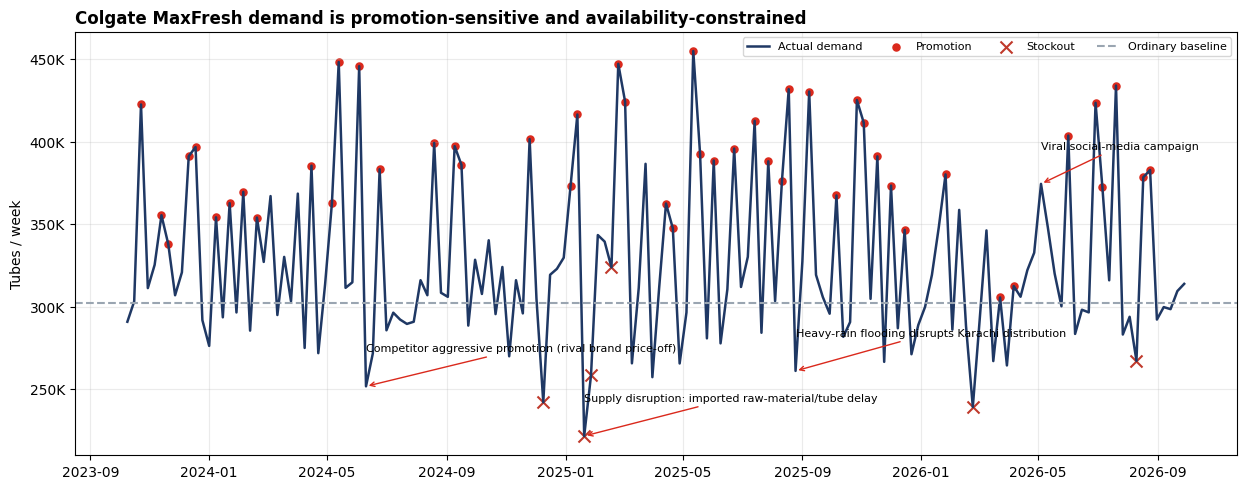

In [1]:

# ============================================================
# SETUP + DATA LOAD + DATA AUDIT + DEMAND PROFILE
# ============================================================
import warnings, os
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
import statsmodels.api as sm
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display, HTML, Markdown

COLGATE_RED = "#DA291C"; DEEP_RED = "#A61912"; NAVY = "#1F3864"; BLUE = "#2F80ED"; TEAL = "#1B998B"; GREEN = "#2E8B57"; GOLD = "#F2B84B"; ORANGE = "#F08A5D"; RISK = "#C0392B"; MID_GREY = "#9AA5B1"; DARK = "#172033"; MUTED = "#667085"; WHITE = "#FFFFFF"; DASH_BG = "#F6F7F9"
BANNER = "Company-Calibrated Synthetic Dataset for Academic Analysis — illustrative figures, calibrated to Colgate-Palmolive (Pakistan)'s disclosed scale, not actual company records."
DATA_FILE_CANDIDATES = [
    "MGT353_Forecasting_M1_MustafaArif_ColgatePalmolive_Data.csv",
    "colgate_maxfresh_weekly_synthetic.csv"
]
DATA_FILE = next((f for f in DATA_FILE_CANDIDATES if os.path.exists(f)), None)
assert DATA_FILE is not None, (
    "Dataset CSV not found. Keep the packaged Data.csv beside this notebook "
    "or upload colgate_maxfresh_weekly_synthetic.csv in Colab."
)
print(f"Using dataset file: {DATA_FILE}")

df = pd.read_csv(DATA_FILE, keep_default_na=False)
df["Week_Start_Date"] = pd.to_datetime(df["Week_Start_Date"])
df = df.sort_values("Week_Start_Date").reset_index(drop=True)
required_cols = ["SKU_ID","Region_Channel","Week_Start_Date","Actual_Demand","Historical_Forecast","Price","Promo_Flag","Promo_Depth","Event_Flag","Event_Label","Distribution_Points","Stockout_Flag","Exceptional_Event"]
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Missing required columns: {missing}"
assert len(df) >= 104
assert df["Week_Start_Date"].diff().dropna().dt.days.eq(7).all()
print(BANNER)
print("Rows:", len(df), "| Date range:", df.Week_Start_Date.min().date(), "to", df.Week_Start_Date.max().date())

N_TEST = 12
train_df = df.iloc[:-N_TEST].copy().reset_index(drop=True)
test_df = df.iloc[-N_TEST:].copy().reset_index(drop=True)
print("Training weeks:", len(train_df), "| Holdout weeks:", len(test_df))

desc = df[["Actual_Demand","Historical_Forecast","Price","Promo_Depth","Distribution_Points"]].agg(["mean","median","std","min","max"]).T
desc["range"] = desc["max"] - desc["min"]
desc["cv"] = desc["std"] / desc["mean"]
display(desc.style.format({"mean":"{:,.0f}","median":"{:,.0f}","std":"{:,.0f}","min":"{:,.0f}","max":"{:,.0f}","range":"{:,.0f}","cv":"{:.1%}"}))

ordinary_mask = (df.Promo_Flag.eq(0) & df.Event_Flag.eq(0) & df.Stockout_Flag.eq(0) & df.Exceptional_Event.astype(str).str.strip().eq(""))
ordinary_mean = df.loc[ordinary_mask, "Actual_Demand"].mean()
demand_cv = df["Actual_Demand"].std() / df["Actual_Demand"].mean()

diagnosis = """Colgate MaxFresh Red Gel 125g demand is not a stable level-only series. Weekly demand has meaningful natural variation around the ordinary-week baseline, while promotional periods create the clearest upward pulses. Ramadan and Eid windows add calendar-driven movement, although their effect is smaller and less consistent than promotion activity. Stockouts and one-off supply or weather shocks visibly suppress observed sales, meaning some low-demand weeks reflect availability constraints rather than weak consumer demand. Price and distribution coverage both change over time, although their joint upward trend creates a multicollinearity concern for regression. Because the series combines changing level, promotional uplift, calendar effects, supply constraints and noise, a naive or simple level-only forecast is unlikely to be sufficient. Model selection should therefore compare simple baselines with trend, seasonal and calendar-aware methods on the same unseen holdout period."""
print("\nDEMAND PATTERN DIAGNOSIS\n", " ".join(diagnosis.split()))
print("Word count:", len(diagnosis.split()))

fig, ax = plt.subplots(figsize=(15,5.5))
ax.plot(df.Week_Start_Date, df.Actual_Demand, color=NAVY, linewidth=1.8, label="Actual demand")
ax.scatter(df.loc[df.Promo_Flag.eq(1),"Week_Start_Date"], df.loc[df.Promo_Flag.eq(1),"Actual_Demand"], color=COLGATE_RED, s=26, label="Promotion")
ax.scatter(df.loc[df.Stockout_Flag.eq(1),"Week_Start_Date"], df.loc[df.Stockout_Flag.eq(1),"Actual_Demand"], color=RISK, s=75, marker="x", label="Stockout")
ax.axhline(ordinary_mean, color=MID_GREY, linestyle="--", label="Ordinary baseline")
for label in ["competitor", "supply", "rain", "viral"]:
    m = df[df.Exceptional_Event.astype(str).str.contains(label, case=False, na=False)]
    if len(m):
        r = m.iloc[0]
        ax.annotate(r.Exceptional_Event, xy=(r.Week_Start_Date, r.Actual_Demand), xytext=(0,25), textcoords="offset points", arrowprops=dict(arrowstyle="->", color=COLGATE_RED), fontsize=8)
ax.set_title("Colgate MaxFresh demand is promotion-sensitive and availability-constrained", loc="left", fontweight="bold")
ax.set_ylabel("Tubes / week")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"{v/1000:,.0f}K"))
ax.grid(alpha=.25); ax.legend(ncol=4, fontsize=8)
plt.show()


In [2]:

# ============================================================
# FORECAST ERROR FUNDAMENTALS + MODEL COMPARISON + VALIDATION
# ============================================================
def forecast_metrics(actual, forecast):
    actual = np.asarray(actual, dtype=float); forecast = np.asarray(forecast, dtype=float)
    error = actual - forecast
    abs_error = np.abs(error)
    mad = abs_error.mean()
    return {"MAD": mad, "MAPE": (abs_error/actual).mean()*100, "RMSE": np.sqrt(np.mean(error**2)), "WAPE": abs_error.sum()/actual.sum()*100, "Bias": error.mean(), "RSFE": error.sum(), "Tracking Signal": error.sum()/mad if mad else np.nan}

hist_metrics = forecast_metrics(df.Actual_Demand.iloc[1:], df.Historical_Forecast.iloc[1:])
print("Historical forecast metrics:")
for k,v in hist_metrics.items(): print(k, f"{v:,.2f}" if isinstance(v,float) else v)

# Forecasting functions
def naive_forecast(y,h): return np.repeat(y[-1], h)
def seasonal_naive_forecast(y,h,season_length=52): return np.array([y[len(y)-season_length+(i%season_length)] for i in range(h)])
def recursive_moving_average(y,h,window=4):
    hist=list(map(float,y)); out=[]
    for _ in range(h):
        fc=np.mean(hist[-window:]); out.append(fc); hist.append(fc)
    return np.asarray(out)
def ses_forecast(y,h,alpha): return np.asarray(SimpleExpSmoothing(y, initialization_method="estimated").fit(smoothing_level=alpha, optimized=False).forecast(h))
def holt_damped_forecast(y,h): return np.asarray(Holt(y, damped_trend=True, initialization_method="estimated").fit(optimized=True).forecast(h))
def holt_winters_forecast(y,h,season_length=52): return np.asarray(ExponentialSmoothing(y, trend="add", seasonal="add", seasonal_periods=season_length, initialization_method="estimated").fit(optimized=True).forecast(h))
def calendar_adjusted_holt(train, future, use_promo=True):
    y=train.Actual_Demand.astype(float).values
    driver_cols=["Event_Flag"]
    if use_promo: driver_cols.append("Promo_Flag")
    driver_cols.append("Stockout_Flag")
    trend_index=np.arange(len(train))/52
    X=np.column_stack([np.ones(len(train)), trend_index] + [train[c].astype(float).values for c in driver_cols])
    beta=np.linalg.lstsq(X, np.log(y), rcond=None)[0]
    effects=dict(zip(driver_cols, beta[2:]))
    historical_effect=np.zeros(len(train))
    for c in driver_cols: historical_effect += effects[c]*train[c].astype(float).values
    adjusted_y=y/np.exp(historical_effect)
    base_model=Holt(adjusted_y, damped_trend=True, initialization_method="estimated").fit(optimized=True)
    base_forecast=np.asarray(base_model.forecast(len(future)))
    future_effect=np.zeros(len(future))
    for c in driver_cols:
        if c=="Stockout_Flag": continue
        if c in future.columns: future_effect += effects[c]*future[c].astype(float).values
    return base_forecast*np.exp(future_effect), effects

train_y = train_df.Actual_Demand.astype(float).values
h=len(test_df)
future_holdout_inputs = test_df[["Week_Start_Date","Promo_Flag","Event_Flag","Stockout_Flag"]].copy()
forecasts = {
    "Naive": naive_forecast(train_y,h),
    "Seasonal Naive": seasonal_naive_forecast(train_y,h,52),
    "Moving Average (4-week recursive)": recursive_moving_average(train_y,h,4),
    "SES α=0.3": ses_forecast(train_y,h,.3),
    "SES α=0.6": ses_forecast(train_y,h,.6),
    "Holt Damped Trend": holt_damped_forecast(train_y,h),
    "Holt-Winters Additive": holt_winters_forecast(train_y,h,52),
    "Event-adjusted Holt": calendar_adjusted_holt(train_df,future_holdout_inputs,use_promo=False)[0],
    "Event+Promo-adjusted Holt": calendar_adjusted_holt(train_df,future_holdout_inputs,use_promo=True)[0]
}
rows=[]
for m,fc in forecasts.items():
    d=forecast_metrics(test_df.Actual_Demand.values, fc); d["Model"]=m; rows.append(d)
model_comparison=pd.DataFrame(rows).set_index("Model").sort_values("WAPE")
managerial_comments = {
    "Naive": "Simple benchmark; ignores promotion, event and trend structure.",
    "Seasonal Naive": "Annual benchmark; sensitive to year-to-year campaign and availability differences.",
    "Moving Average (4-week recursive)": "Smooths noise but lags sudden promotion-driven changes.",
    "SES α=0.3": "Stable level model; cannot explicitly represent promotions or events.",
    "SES α=0.6": "More responsive to recent demand but can react to short-term noise.",
    "Holt Damped Trend": "Captures changing level/trend while damping long-horizon extrapolation.",
    "Holt-Winters Additive": "Captures recurring annual seasonality without future actual demand.",
    "Event-adjusted Holt": "Uses known event-calendar inputs while controlling historical stockout distortion.",
    "Event+Promo-adjusted Holt": "Best holdout accuracy; valid when planned promotion/event inputs are known at forecast origin."
}
model_comparison["Managerial Comment"] = [managerial_comments[m] for m in model_comparison.index]
selected_model=model_comparison.index[0]
selected_forecast=forecasts[selected_model]
print("Selected model:", selected_model)
display(model_comparison.style.format({"MAD":"{:,.0f}","MAPE":"{:.2f}%","RMSE":"{:,.0f}","WAPE":"{:.2f}%","Bias":"{:,.0f}","RSFE":"{:,.0f}","Tracking Signal":"{:.2f}"}))

holdout_diag=test_df.copy()
holdout_diag["Forecast"]=np.round(selected_forecast)
holdout_diag["Error"]=holdout_diag.Actual_Demand-holdout_diag.Forecast
holdout_diag["Abs_Error"]=holdout_diag.Error.abs()
def diagnose_miss(r):
    if r.Stockout_Flag==1: return "Stockout constrained observed demand."
    if r.Promo_Flag==1 and r.Error>0: return "Promotion uplift stronger than expected."
    if r.Promo_Flag==1 and r.Error<0: return "Promotion underperformed expected uplift."
    if r.Event_Flag==1: return "Calendar-event demand differed from historical pattern."
    if str(r.Exceptional_Event).strip(): return "Exceptional event not fully captured."
    return "Residual week-to-week variation."
holdout_diag["Diagnosis"]=holdout_diag.apply(diagnose_miss, axis=1)
top5_misses=holdout_diag.nlargest(5,"Abs_Error")
display(top5_misses[["Week_Start_Date","Actual_Demand","Forecast","Error","Promo_Flag","Event_Flag","Stockout_Flag","Exceptional_Event","Diagnosis"]])
print("Leakage audit: train-only fitting, common 12-week holdout, recursive moving average, known planned promo/event inputs only, no future Actual_Demand used for fitting.")


Historical forecast metrics:
MAD 39,717.62
MAPE 12.96
RMSE 49,751.56
WAPE 12.06
Bias -19,385.46
RSFE -3,004,747.00
Tracking Signal -75.65
Selected model: Event+Promo-adjusted Holt


,MAD,MAPE,RMSE,WAPE,Bias,RSFE,Tracking Signal,Managerial Comment
Model,,,,,,,,
Event+Promo-adjusted Holt,"14,269",4.40%,"19,070",4.43%,"-1,021","-12,248",-0.86,Best holdout accuracy; valid when planned promotion/event inputs are known at forecast origin.
Holt Damped Trend,"41,680",12.69%,"47,960",12.93%,"-7,328","-87,938",-2.11,Captures changing level/trend while damping long-horizon extrapolation.
Event-adjusted Holt,"43,278",13.30%,"48,551",13.42%,"-10,523","-126,278",-2.92,Uses known event-calendar inputs while controlling historical stockout distortion.
Holt-Winters Additive,"50,546",15.17%,"65,726",15.68%,"-9,205","-110,459",-2.19,Captures recurring annual seasonality without future actual demand.
SES α=0.3,"53,654",17.24%,"56,786",16.64%,"-31,276","-375,314",-7.00,Stable level model; cannot explicitly represent promotions or events.
Moving Average (4-week recursive),"58,689",19.19%,"64,021",18.20%,"-41,554","-498,652",-8.50,Smooths noise but lags sudden promotion-driven changes.
Naive,"63,093",20.83%,"69,006",19.57%,"-50,153","-601,838",-9.54,"Simple benchmark; ignores promotion, event and trend structure."
SES α=0.6,"63,427",20.96%,"69,493",19.67%,"-50,821","-609,853",-9.62,More responsive to recent demand but can react to short-term noise.
Seasonal Naive,"71,138",21.81%,"87,366",22.07%,"-22,231","-266,776",-3.75,Annual benchmark; sensitive to year-to-year campaign and availability differences.


,Week_Start_Date,Actual_Demand,Forecast,Error,Promo_Flag,Event_Flag,Stockout_Flag,Exceptional_Event,Diagnosis
1,2026-07-20,434028,388077.0,45951.0,1,0,0,,Promotion uplift stronger than expected.
4,2026-08-10,267142,301871.0,-34729.0,0,0,1,,Stockout constrained observed demand.
2,2026-07-27,283072,301871.0,-18799.0,0,0,0,,Residual week-to-week variation.
0,2026-07-13,315945,301871.0,14074.0,0,0,0,,Residual week-to-week variation.
11,2026-09-28,313792,301871.0,11921.0,0,0,0,,Residual week-to-week variation.


Leakage audit: train-only fitting, common 12-week holdout, recursive moving average, known planned promo/event inputs only, no future Actual_Demand used for fitting.


In [3]:

# ============================================================
# MULTIPLE REGRESSION + DRIVER INTERPRETATION
# ============================================================
REGRESSORS = ["Price","Promo_Flag","Event_Flag","Distribution_Points"]
X = sm.add_constant(train_df[REGRESSORS].astype(float))
y = train_df.Actual_Demand.astype(float)
reg_model = sm.OLS(y, X).fit()
r2 = reg_model.rsquared; adj_r2 = reg_model.rsquared_adj
reg_table = pd.DataFrame({"Coefficient":reg_model.params,"p-value":reg_model.pvalues})
display(reg_table.style.format({"Coefficient":"{:,.3f}","p-value":"{:.6f}"}))
print(f"R-squared: {r2:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")
print("Promotion coefficient:", f"{reg_model.params['Promo_Flag']:+,.0f}", "tubes/week")
print("Event coefficient:", f"{reg_model.params['Event_Flag']:+,.0f}", "tubes/week")
print("Price +PKR10 effect:", f"{reg_model.params['Price']*10:+,.0f}", "tubes/week")
print("Distribution +5K effect:", f"{reg_model.params['Distribution_Points']*5:+,.0f}", "tubes/week")
print("Caveat: associations, not causal effects. Potential confounders include competitor promotions, retailer inventory, media spend, rainfall/distribution disruption and category growth.")


,Coefficient,p-value
const,"106,359.195",0.550813
Price,-253.758,0.342941
Promo_Flag,"88,619.189",0.000000
Event_Flag,"14,836.214",0.043295
Distribution_Points,"1,413.355",0.281227


R-squared: 0.6439
Adjusted R-squared: 0.6336
Promotion coefficient: +88,619 tubes/week
Event coefficient: +14,836 tubes/week
Price +PKR10 effect: -2,538 tubes/week
Distribution +5K effect: +7,067 tubes/week
Caveat: associations, not causal effects. Potential confounders include competitor promotions, retailer inventory, media spend, rainfall/distribution disruption and category growth.


In [4]:

# ============================================================
# TRUE FORWARD FORECAST + STRESS TEST + DECISION
# ============================================================
future_dates = pd.date_range(start=df.Week_Start_Date.max()+pd.Timedelta(days=7), periods=12, freq="W-MON")
forward_calendar = pd.DataFrame({"Week_Start_Date": future_dates})
forward_calendar["Event_Flag"] = 0
forward_calendar["Promo_Flag"] = 0
forward_calendar.loc[[2,6,10], "Promo_Flag"] = 1
forward_calendar["Stockout_Flag"] = 0

forward_forecast, forward_effects = calendar_adjusted_holt(df, forward_calendar, use_promo=True)
forward_df = forward_calendar.copy()
forward_df["Forecast_Demand"] = np.round(forward_forecast)
holdout_errors = test_df.Actual_Demand.values - selected_forecast
band_width = 1.96*np.std(holdout_errors, ddof=1)
forward_df["Lower_Band"] = np.maximum(0, forward_df.Forecast_Demand-band_width).round()
forward_df["Upper_Band"] = (forward_df.Forecast_Demand+band_width).round()

base_total = float(forward_df.Forecast_Demand.sum())
avg_weekly = float(forward_df.Forecast_Demand.mean())
peak_weekly = float(forward_df.Forecast_Demand.max())
peak_week_date = forward_df.loc[forward_df.Forecast_Demand.idxmax(), "Week_Start_Date"]
commit_90 = base_total*.90
flex_10 = base_total*.10
two_week_safety_stock = avg_weekly*2
upside_10 = base_total*1.10
upside_exposure = upside_10-base_total
promo_multiplier = np.where(forward_df.Promo_Flag.eq(1), 1.15, 1.00)
promo_shock_total = forward_df.Forecast_Demand.mul(promo_multiplier).sum()
promo_shock_exposure = promo_shock_total-base_total
supply_loss_exposure = avg_weekly*2

print("FINAL MODEL + FORWARD-PLANNING OUTPUTS")
print("--------------------------------------")
print(f"SELECTED MODEL: {selected_model}")
print(f"Holdout WAPE: {model_comparison.loc[selected_model, 'WAPE']:.2f}%")
print(f"Holdout MAPE: {model_comparison.loc[selected_model, 'MAPE']:.2f}%")
print(f"Holdout MAD: {model_comparison.loc[selected_model, 'MAD']:,.0f} tubes")
print(f"Tracking Signal: {model_comparison.loc[selected_model, 'Tracking Signal']:.2f}")
print(f"R-squared: {r2:.4f}")
print(f"Adjusted R-squared: {adj_r2:.4f}")
print(f"Next 12-week forecast: {base_total:,.0f} tubes")
print(f"Average weekly forecast: {avg_weekly:,.0f} tubes")
print(f"Peak weekly forecast: {peak_weekly:,.0f} tubes")
print(f"Peak week date: {peak_week_date:%d %b %Y}")
print(f"Recommended committed volume: {commit_90:,.0f} tubes")
print(f"Flexible volume retained: {flex_10:,.0f} tubes")
print(f"Two-week safety stock: {two_week_safety_stock:,.0f} tubes")
print(f"Upside +10% exposure: {upside_exposure:,.0f} tubes")
print(f"Promo-week incremental exposure: {promo_shock_exposure:,.0f} tubes")
print(f"2-week supply-loss exposure: {supply_loss_exposure:,.0f} tubes")

display(forward_df.style.format({"Forecast_Demand":"{:,.0f}","Lower_Band":"{:,.0f}","Upper_Band":"{:,.0f}"}))

# Mandatory stress-test table with operational consequences
downside_10 = base_total * 0.90
stress_table = pd.DataFrame({
    "Scenario": [
        "Downside -10%",
        "Base Forecast",
        "Upside +10%",
        "Planned Promo Weeks +15%",
        "2-Week Supply Disruption"
    ],
    "Demand / Exposure": [
        downside_10,
        base_total,
        upside_10,
        promo_shock_total,
        supply_loss_exposure
    ],
    "Operational Consequence": [
        "90% firm commitment remains aligned with the downside case; 10% flexibility limits excess-stock risk.",
        "Base procurement and distributor-replenishment requirement.",
        f"Requires about {upside_exposure:,.0f} additional tubes above the base plan.",
        f"Requires about {promo_shock_exposure:,.0f} additional tubes if planned promotions outperform by 15%.",
        f"Potential shortage of about {supply_loss_exposure:,.0f} tubes; exceeds the flexible pool and requires separate safety stock or alternate supply."
    ]
})
print("\nSTRESS TEST — OPERATIONAL CONSEQUENCES")
display(stress_table.style.format({"Demand / Exposure":"{:,.0f}"}))


FINAL MODEL + FORWARD-PLANNING OUTPUTS
--------------------------------------
SELECTED MODEL: Event+Promo-adjusted Holt
Holdout WAPE: 4.43%
Holdout MAPE: 4.40%
Holdout MAD: 14,269 tubes
Tracking Signal: -0.86
R-squared: 0.6439
Adjusted R-squared: 0.6336
Next 12-week forecast: 3,883,026 tubes
Average weekly forecast: 323,586 tubes
Peak weekly forecast: 388,735 tubes
Peak week date: 19 Oct 2026
Recommended committed volume: 3,494,723 tubes
Flexible volume retained: 388,303 tubes
Two-week safety stock: 647,171 tubes
Upside +10% exposure: 388,303 tubes
Promo-week incremental exposure: 174,931 tubes
2-week supply-loss exposure: 647,171 tubes


,Week_Start_Date,Event_Flag,Promo_Flag,Stockout_Flag,Forecast_Demand,Lower_Band,Upper_Band
0,2026-10-05 00:00:00,0,0,0,"301,869","262,886","340,852"
1,2026-10-12 00:00:00,0,0,0,"301,869","262,886","340,852"
2,2026-10-19 00:00:00,0,1,0,"388,735","349,752","427,718"
3,2026-10-26 00:00:00,0,0,0,"301,869","262,886","340,852"
4,2026-11-02 00:00:00,0,0,0,"301,869","262,886","340,852"
5,2026-11-09 00:00:00,0,0,0,"301,869","262,886","340,852"
6,2026-11-16 00:00:00,0,1,0,"388,735","349,752","427,718"
7,2026-11-23 00:00:00,0,0,0,"301,869","262,886","340,852"
8,2026-11-30 00:00:00,0,0,0,"301,869","262,886","340,852"
9,2026-12-07 00:00:00,0,0,0,"301,869","262,886","340,852"



STRESS TEST — OPERATIONAL CONSEQUENCES


,Scenario,Demand / Exposure,Operational Consequence
0,Downside -10%,"3,494,723",90% firm commitment remains aligned with the downside case; 10% flexibility limits excess-stock risk.
1,Base Forecast,"3,883,026",Base procurement and distributor-replenishment requirement.
2,Upside +10%,"4,271,329","Requires about 388,303 additional tubes above the base plan."
3,Planned Promo Weeks +15%,"4,057,957","Requires about 174,931 additional tubes if planned promotions outperform by 15%."
4,2-Week Supply Disruption,"647,171","Potential shortage of about 647,171 tubes; exceeds the flexible pool and requires separate safety stock or alternate supply."


In [5]:

# ============================================================
# DASHBOARD DELIVERABLE NOTE
# ============================================================
# The final interactive executive dashboard is exported separately as:
# MGT353_Forecasting_M1_MustafaArif_ColgatePalmolive_Dashboard.html
# It uses the locked model/forecast values from the cells above and presents:
# history, holdout validation, forward forecast, model comparison, forecast error,
# regression drivers, stress tests and the final management decision.

print("Dashboard deliverable created separately as standalone HTML.")
print("Core dashboard KPIs:")
print(f"Next 12 weeks: {base_total:,.0f} tubes")
print(f"Commit now: {commit_90:,.0f} tubes")
print(f"Flexible volume: {flex_10:,.0f} tubes")
print(f"Promotion readiness: {promo_shock_exposure:,.0f} tubes")
print(f"Severe supply cover: {two_week_safety_stock:,.0f} tubes")


Dashboard deliverable created separately as standalone HTML.
Core dashboard KPIs:
Next 12 weeks: 3,883,026 tubes
Commit now: 3,494,723 tubes
Flexible volume: 388,303 tubes
Promotion readiness: 174,931 tubes
Severe supply cover: 647,171 tubes


## Final recommendation
Use the Event+Promo-adjusted Holt model as the primary 12-week planning model. Plan against approximately **3.88M tubes**, commit **3.49M tubes**, retain **388K tubes** as flexible volume, maintain approximately **175K tubes** of promotion readiness, and recognize that a severe two-week supply interruption requires separate cover of approximately **647K tubes**.